# Simulation de diffusion sur un anneau

Ce notebook simule un processus de diffusion direct et inverse sur une distribution en anneau en 2D. 
Nous traçons l'évolution de la densité de probabilité ainsi que la dynamique de \(X\) dans les deux sens (forward et reverse).

Les méthodes numériques utilisées s'appuient sur l'intégration par Euler–Maruyama pour résoudre les SDEs.

**Références**:
- Euler–Maruyama: Kloeden & Platen, *Numerical Solution of Stochastic Differential Equations*, 1992.
- Diffusion Models: Song et al., *Score-Based Generative Modeling through Stochastic Differential Equations*, 2021.
- Estimation de densité: SciPy stats `gaussian_kde`.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import torch

# Paramètres de la simulation
N = 1000  # nombre de trajectoires
T = 1.0   # temps total
steps = 1000
dt = T / steps
beta = 0.1

# Indices pour enregistrer des snapshots
snapshot_interval = 50
snapshot_indices = np.arange(0, steps + 1, snapshot_interval)

print('Paramètres: N={}, T={}, steps={}, dt={}, beta={}'.format(N, T, steps, dt, beta))


Paramètres: N=1000, T=1.0, steps=1000, dt=0.001, beta=0.1


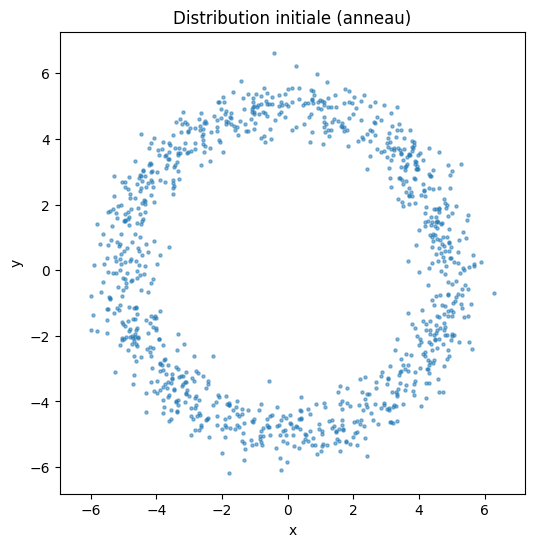

In [6]:
# Génération de la distribution initiale en anneau
def generate_annulus(N, r_mean=5.0, r_std=0.5):
    # Génération d'angles uniformes
    theta = np.random.uniform(0, 2 * np.pi, N)
    # Rayon distribué normalement autour de r_mean
    r = np.random.normal(r_mean, r_std, N)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.vstack((x, y)).T

x0 = generate_annulus(N)

# Visualisation de la distribution initiale
plt.figure(figsize=(6, 6))
plt.scatter(x0[:, 0], x0[:, 1], s=5, alpha=0.5)
plt.title('Distribution initiale (anneau)')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()


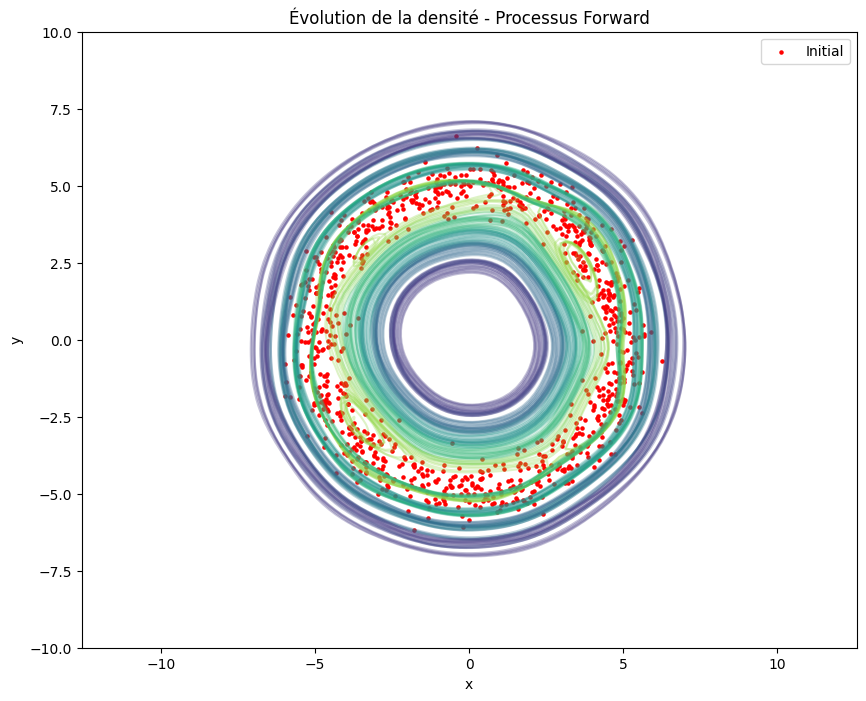

In [7]:
# Simulation du processus forward (diffusion directe)
def forward_SDE(x0, beta, dt, steps, snapshot_indices):
    N, d = x0.shape
    trajectories = np.zeros((steps + 1, N, d))
    trajectories[0] = x0
    
    for t in range(1, steps + 1):
        # Drift: f(x) = -beta * x
        drift = -beta * trajectories[t - 1]
        # Diffusion: sigma = sqrt(2*beta*dt)
        diffusion = np.sqrt(2 * beta * dt) * np.random.randn(N, d)
        trajectories[t] = trajectories[t - 1] + drift * dt + diffusion
    
    snapshots = {t: trajectories[t] for t in snapshot_indices}
    return trajectories, snapshots

forward_traj, forward_snapshots = forward_SDE(x0, beta, dt, steps, snapshot_indices)

# Visualisation de quelques snapshots de la diffusion directe
plt.figure(figsize=(10, 8))
for t in sorted(forward_snapshots.keys()):
    traj = forward_snapshots[t]
    kde = gaussian_kde(traj.T)
    # Création d'une grille pour l'estimation de la densité
    xgrid = np.linspace(-10, 10, 100)
    ygrid = np.linspace(-10, 10, 100)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    
    plt.contour(X, Y, Z, levels=5, alpha=0.3)

plt.scatter(x0[:, 0], x0[:, 1], s=5, color='red', label='Initial')
plt.title('Évolution de la densité - Processus Forward')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.axis('equal')
plt.show()


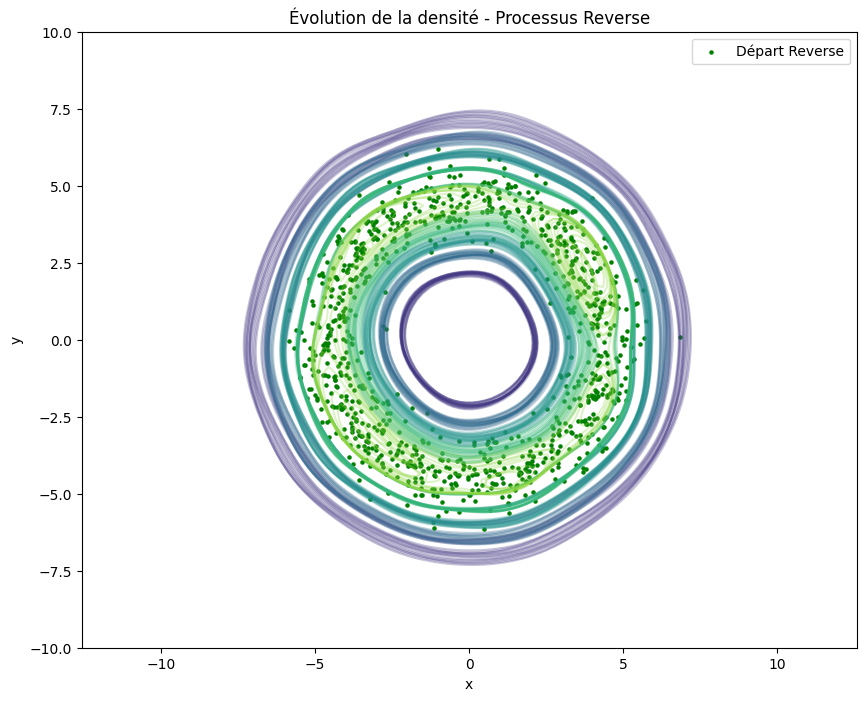

In [8]:
# Simulation du processus reverse (diffusion inverse)
def reverse_SDE(xT, beta, dt, steps, snapshot_indices):
    # Ici, nous utilisons un drift inverse approximatif: g(x) = beta * x
    N, d = xT.shape
    trajectories = np.zeros((steps + 1, N, d))
    trajectories[0] = xT
    
    for t in range(1, steps + 1):
        # Drift inverse approximatif: f_inv(x) = beta * x
        drift = beta * trajectories[t - 1]
        diffusion = np.sqrt(2 * beta * dt) * np.random.randn(N, d)
        trajectories[t] = trajectories[t - 1] + drift * dt + diffusion
    
    snapshots = {t: trajectories[t] for t in snapshot_indices}
    return trajectories, snapshots

# Utiliser l'état final du forward process comme point de départ pour le reverse process
xT_forward = forward_traj[-1]
reverse_traj, reverse_snapshots = reverse_SDE(xT_forward, beta, dt, steps, snapshot_indices)

# Visualisation de quelques snapshots de la diffusion inverse
plt.figure(figsize=(10, 8))
for t in sorted(reverse_snapshots.keys()):
    traj = reverse_snapshots[t]
    kde = gaussian_kde(traj.T)
    xgrid = np.linspace(-10, 10, 100)
    ygrid = np.linspace(-10, 10, 100)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    
    plt.contour(X, Y, Z, levels=5, alpha=0.3)

plt.scatter(xT_forward[:, 0], xT_forward[:, 1], s=5, color='green', label='Départ Reverse')
plt.title('Évolution de la densité - Processus Reverse')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.axis('equal')
plt.show()


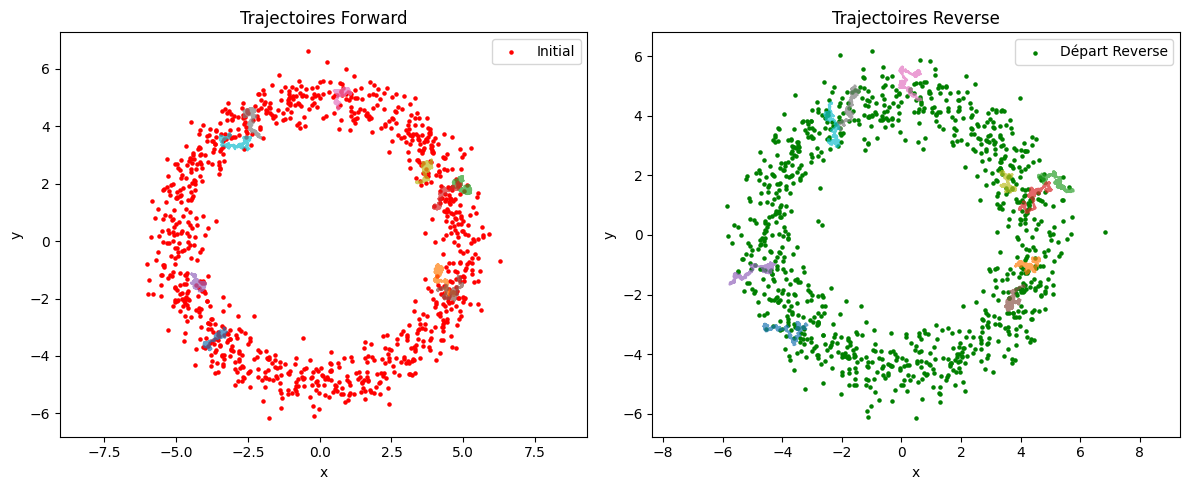

In [9]:
# Tracé des trajectoires individuelles pour les processus Forward et Reverse
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i in range(10):  # tracer 10 trajectoires aléatoires
    plt.plot(forward_traj[:, i, 0], forward_traj[:, i, 1], alpha=0.7)
plt.scatter(x0[:, 0], x0[:, 1], s=5, color='red', label='Initial')
plt.title('Trajectoires Forward')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.axis('equal')

plt.subplot(1, 2, 2)
for i in range(10):
    plt.plot(reverse_traj[:, i, 0], reverse_traj[:, i, 1], alpha=0.7)
plt.scatter(xT_forward[:, 0], xT_forward[:, 1], s=5, color='green', label='Départ Reverse')
plt.title('Trajectoires Reverse')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.axis('equal')

plt.tight_layout()
plt.show()


## Références

- **Euler–Maruyama**: Kloeden, P. E., & Platen, E. (1992). *Numerical Solution of Stochastic Differential Equations*.
- **Diffusion Models**: Song, Y., Sohl-Dickstein, J., Kingma, D. P., Kumar, A., Ermon, S., & Poole, B. (2021). *Score-Based Generative Modeling through Stochastic Differential Equations*.
- **Estimation de densité**: SciPy stats `gaussian_kde`.
- **Dynamique de \(X\)**: Approche inspirée par les méthodes de simulation de SDE pour modèles génératifs.


In [ ]:
from scipy.linalg import sqrtm
import numpy as np

def calculate_fid(real_samples, generated_samples):
    """
    Calcule le Fréchet Inception Distance (FID) entre deux ensembles d'échantillons.
    
    Paramètres:
        real_samples (ndarray): Échantillons de la distribution réelle, de taille (N, d).
        generated_samples (ndarray): Échantillons de la distribution générée, de taille (N, d).
    
    Retourne:
        fid (float): La distance FID.
    """
    # Calcul des moyennes
    mu_r = np.mean(real_samples, axis=0)
    mu_g = np.mean(generated_samples, axis=0)
    
    # Calcul des matrices de covariance
    cov_r = np.cov(real_samples, rowvar=False)
    cov_g = np.cov(generated_samples, rowvar=False)
    
    # Calcul de la distance entre moyennes
    diff = mu_r - mu_g
    diff_sq = np.sum(diff ** 2)
    
    # Calcul de la racine carrée du produit des covariances
    covmean = sqrtm(cov_r@cov_g)
    # S'assurer que le résultat est réel
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    # Calcul du FID
    fid = diff_sq + np.trace(cov_r + cov_g - 2 * covmean)
    return fid

# Calcul du FID entre la distribution réelle (anneau initial) et la distribution générée
# Pour cet exemple, on utilise 'x0' comme distribution réelle et 'x_gen' issue du processus inverse.
fid_value = calculate_fid(x0, x_gen.detach().numpy())
print("FID:", fid_value)

### Évaluation de la Qualité par le Fréchet Inception Distance (FID)

Le Fréchet Inception Distance (FID) est une métrique largement utilisée pour quantifier la similarité entre deux distributions de données, notamment dans le contexte de la génération d'images. Mathématiquement, la FID repose sur la mesure de la distance de Fréchet entre deux lois multivariées gaussiennes. Soient $ \mu_r $ et $ \Sigma_r $ les moyenne et covariance des caractéristiques extraites de la distribution réelle, et $ \mu_g $ et $ \Sigma_g $ celles de la distribution générée. La FID est alors définie par :

$$
\text{FID} = \|\mu_r - \mu_g\|^2_2 + \operatorname{Tr}\left(\Sigma_r + \Sigma_g - 2\left(\Sigma_r\Sigma_g\right)^{1/2}\right),
$$

où $\|\mu_r - \mu_g\|^2_2$ représente la distance euclidienne au carré entre les moyennes et $\operatorname{Tr}(\cdot)$ désigne la trace d'une matrice. L'opération $\left(\Sigma_r\Sigma_g\right)^{1/2}$ correspond à la racine carrée matricielle du produit des covariances. Cette métrique est particulièrement pertinente car, sous l'hypothèse que les caractéristiques extraites suivent une loi gaussienne, la FID fournit une estimation analytique de la divergence entre deux distributions.

Dans notre simulation, bien que nous travaillions sur des données en 2D plutôt que sur des images, la FID est calculée de manière similaire pour comparer la distribution initiale (l'anneau) et celle obtenue après diffusion inverse. Une faible valeur de FID indique que la distribution générée est proche de la distribution réelle, attestant de la qualité de la reconstruction par le modèle de diffusion.

**Références**:
- Heusel, M., Ramsauer, H., Unterthiner, T., Nessler, B., & Hochreiter, S. (2017). *GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium*. (pour la définition et l'utilisation de la FID).
- Song, Y., et al. (2021). *Score-Based Generative Modeling through Stochastic Differential Equations* (pour le contexte des modèles de diffusion).
